# SentinelAI — المرحلة ٣ (جزء أ): النماذج الخاضعة للإشراف (Supervised)

في هذا الملف ندرّب **٣ خوارزميات Supervised فقط**:

1. Random Forest
2. Logistic Regression
3. Gradient Boosting

**لن ندرّب** خوارزميات Unsupervised (K-Means, DBSCAN, Isolation Forest) ولا شبكة
الـ CNN في هذا الملف — تلك ستكون في ملفات لاحقة منفصلة.

نستخدم بيانات `data/processed/` الجاهزة من المرحلة ٢ (مقسّمة، مُقاسة بـ StandardScaler)،
وأوزان الفئات المحفوظة (`class_weights.json`) لمعالجة عدم توازن البيانات.

In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)

sns.set_theme(style="whitegrid")

PROCESSED_DIR = os.path.join("..", "data", "processed")
MODELS_DIR = os.path.join("..", "models")
os.makedirs(MODELS_DIR, exist_ok=True)

RANDOM_STATE = 42

**ماذا فعلنا ولماذا؟**
استوردنا الخوارزميات الثلاث المطلوبة: `RandomForestClassifier` و `LogisticRegression` من
`scikit-learn`، و `XGBClassifier` من مكتبة `xgboost`. بخصوص "Gradient Boosting": ملف
`CLAUDE.md` يذكرها كخيار **"Gradient Boosting / XGBoost"** (أي أنهما بديلان لنفس
الخوارزمية)، واخترنا تحديداً **XGBoost** بدل `GradientBoostingClassifier` التقليدي في
scikit-learn لأن الأخير بطيء جداً على بيانات بهذا الحجم (~900 ألف صف، 11 فئة) وقد يستغرق
ساعات، بينما XGBoost يستخدم خوارزمية أسرع بكثير (Histogram-based) وينتج نفس فكرة
Gradient Boosting عملياً. سنشير لهذا النموذج في كل مكان باسم **"Gradient Boosting (XGBoost)"**
ليكون واضحاً. استوردنا أيضاً `LabelEncoder` — سنحتاجه فقط مع XGBoost لسبب سنشرحه لاحقاً.

In [2]:
X_train = np.load(os.path.join(PROCESSED_DIR, "X_train.npy"))
X_test = np.load(os.path.join(PROCESSED_DIR, "X_test.npy"))
y_train = np.load(os.path.join(PROCESSED_DIR, "y_train.npy"))
y_test = np.load(os.path.join(PROCESSED_DIR, "y_test.npy"))

with open(os.path.join(PROCESSED_DIR, "feature_names.json"), encoding="utf-8") as f:
    feature_names = json.load(f)

with open(os.path.join(PROCESSED_DIR, "label_mapping.json"), encoding="utf-8") as f:
    label_mapping = {int(k): v for k, v in json.load(f).items()}

with open(os.path.join(PROCESSED_DIR, "class_weights.json"), encoding="utf-8") as f:
    class_weights = {int(k): v for k, v in json.load(f).items()}

classes_sorted = sorted(label_mapping.keys())
class_names_sorted = [label_mapping[c] for c in classes_sorted]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")
print(f"عدد الفئات: {len(classes_sorted)} -> {class_names_sorted}")

X_train: (908327, 77), X_test: (227082, 77)
y_train: (908327,), y_test: (227082,)
عدد الفئات: 11 -> ['Benign', 'Attack_2', 'Attack_3', 'Attack_4', 'Attack_5', 'Attack_6', 'Attack_7', 'Attack_8', 'Attack_9', 'Attack_10', 'Attack_11']


**ماذا فعلنا ولماذا؟**
حمّلنا بيانات التدريب/الاختبار الجاهزة (مُقاسة مسبقاً) وأسماء الخصائص وأوزان الفئات التي
حفظناها في المرحلة ٢، بدل إعادة تنظيف وتقسيم البيانات من جديد. هذا يضمن أن كل النماذج
الثلاثة تتدرب وتُختبر على **نفس البيانات بالضبط**، مما يجعل المقارنة بينها عادلة.

In [3]:
# لـ RandomForest و LogisticRegression نستخدم class_weight مباشرة.
# لـ XGBoost لا يوجد معامل class_weight، لذلك نحوّل نفس الأوزان إلى sample_weight
# (وزن لكل صف حسب فئته) باستخدام نفس القاموس المحفوظ من المرحلة ٢.
sample_weight_train = np.array([class_weights[label] for label in y_train])

print("مثال على أول 5 قيم sample_weight المقابلة لأول 5 فئات في y_train:")
print(pd.DataFrame({"Label": y_train[:5], "sample_weight": sample_weight_train[:5]}))

مثال على أول 5 قيم sample_weight المقابلة لأول 5 فئات في y_train:
   Label  sample_weight
0      1       0.117286
1      1       0.117286
2      1       0.117286
3      1       0.117286
4      4       0.830536


**ماذا فعلنا ولماذا؟**
الأوزان المحفوظة في `class_weights.json` هي وزن واحد لكل فئة (11 قيمة). حوّلناها هنا إلى
مصفوفة وزن **لكل صف** في `y_train` (908,327 قيمة) لأن `XGBClassifier.fit()` يطلب
`sample_weight` بحجم البيانات نفسه، وليس قاموساً. القيم المستخدمة **نفسها تماماً** التي
سنمررها لـ RandomForest و LogisticRegression عبر `class_weight`، فقط بصيغة مختلفة.

In [4]:
results = {}
trained_models = {}

def evaluate_model(name, y_pred, y_test):
    """نستقبل التوقعات y_pred جاهزة (بمساحة الفئات الأصلية 1..11) بدل استدعاء
    model.predict() هنا، لأن XGBoost يحتاج خطوة ترميز/فك ترميز إضافية قبل هذه الدالة."""
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )

    print(f"===== {name} =====")
    print(f"Accuracy:          {acc:.4f}")
    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall (macro):    {recall:.4f}")
    print(f"F1-score (macro):  {f1:.4f}\n")
    print(classification_report(
        y_test, y_pred, labels=classes_sorted, target_names=class_names_sorted,
        zero_division=0,
    ))

    cm = confusion_matrix(y_test, y_pred, labels=classes_sorted)
    plt.figure(figsize=(9, 7))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names_sorted, yticklabels=class_names_sorted,
    )
    plt.xlabel("التصنيف المتوقَّع (Predicted)")
    plt.ylabel("التصنيف الحقيقي (Actual)")
    plt.title(f"مصفوفة الالتباس (Confusion Matrix) — {name}")
    plt.tight_layout()
    plt.show()

    return {"Accuracy": acc, "Precision (macro)": precision,
            "Recall (macro)": recall, "F1-score (macro)": f1}

**ماذا فعلنا ولماذا؟**
كتبنا دالة واحدة `evaluate_model` نستخدمها مع كل نموذج من النماذج الثلاثة، حتى لا نكرر
نفس الكود ثلاث مرات. تحسب الدالة Accuracy وPrecision/Recall/F1 بطريقة **Macro Average**
(يعني: تحسب المقياس لكل فئة على حدة ثم تأخذ المتوسط بينها بوزن متساوٍ لكل فئة) — وهذا
أفضل من المتوسط العادي (Micro/Weighted) هنا لأن البيانات غير متوازنة: لو استخدمنا مقياساً
عادياً، فئة `Benign` الضخمة كانت ستُخفي ضعف النموذج في اكتشاف الهجمات النادرة. كما ترسم
الدالة مصفوفة التباس (Confusion Matrix) لنرى بالضبط أي فئات يخلط النموذج بينها.

وقت تدريب Random Forest: 57.0 ثانية


===== Random Forest =====
Accuracy:          0.9995
Precision (macro): 0.8515
Recall (macro):    0.9592
F1-score (macro):  0.8802

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    176012
    Attack_2       1.00      1.00      1.00      7026
    Attack_3       1.00      1.00      1.00      6763
    Attack_4       1.00      1.00      1.00     24856
    Attack_5       1.00      1.00      1.00     10410
    Attack_6       1.00      1.00      1.00      1520
    Attack_7       1.00      1.00      1.00       406
    Attack_8       1.00      1.00      1.00        60
    Attack_9       0.17      0.67      0.27        18
   Attack_10       0.80      0.89      0.84         9
   Attack_11       0.40      1.00      0.57         2

    accuracy                           1.00    227082
   macro avg       0.85      0.96      0.88    227082
weighted avg       1.00      1.00      1.00    227082



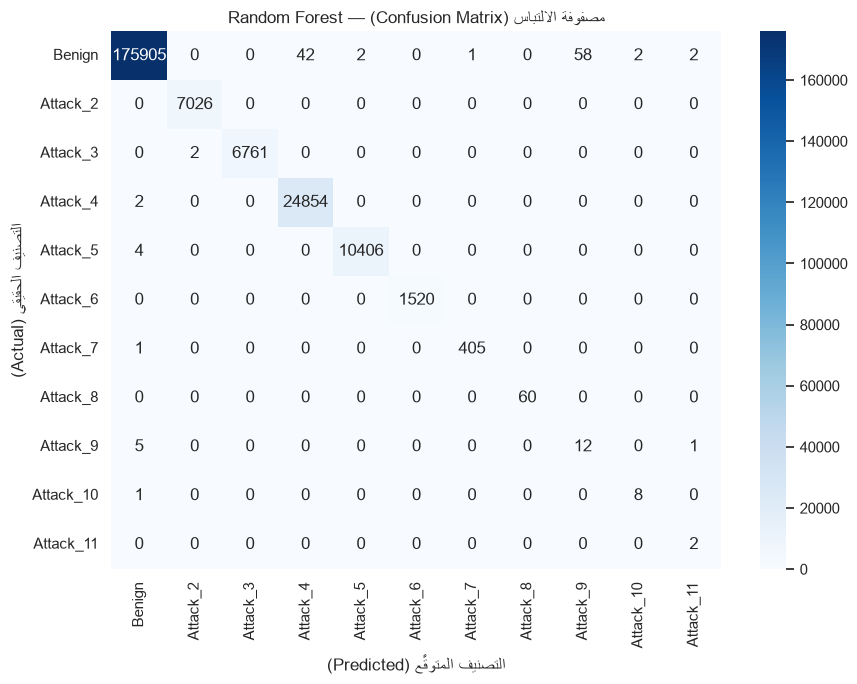

In [5]:
start = time.time()
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight=class_weights,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start
print(f"وقت تدريب Random Forest: {rf_train_time:.1f} ثانية")

trained_models["Random Forest"] = rf_model
rf_pred = rf_model.predict(X_test)
metrics = evaluate_model("Random Forest", rf_pred, y_test)
metrics["Training Time (s)"] = rf_train_time
results["Random Forest"] = metrics

**ماذا فعلنا ولماذا؟**
دربنا Random Forest بـ 200 شجرة (`n_estimators=200`)، ومررنا `class_weight=class_weights`
مباشرة (القاموس المحفوظ من المرحلة ٢) حتى تعطي الشجرة اهتماماً أكبر للهجمات النادرة عند
بناء كل شجرة. استخدمنا `n_jobs=-1` لاستغلال كل أنوية المعالج المتاحة وتسريع التدريب.

وقت تدريب Logistic Regression: 288.6 ثانية
===== Logistic Regression =====
Accuracy:          0.9353
Precision (macro): 0.6895
Recall (macro):    0.9619
F1-score (macro):  0.7045

              precision    recall  f1-score   support

      Benign       1.00      0.92      0.96    176012
    Attack_2       1.00      1.00      1.00      7026
    Attack_3       1.00      1.00      1.00      6763
    Attack_4       0.98      1.00      0.99     24856
    Attack_5       0.88      1.00      0.94     10410
    Attack_6       0.99      1.00      0.99      1520
    Attack_7       0.73      1.00      0.84       406
    Attack_8       1.00      1.00      1.00        60
    Attack_9       0.00      0.67      0.01        18
   Attack_10       0.00      1.00      0.00         9
   Attack_11       0.01      1.00      0.03         2

    accuracy                           0.94    227082
   macro avg       0.69      0.96      0.70    227082
weighted avg       0.99      0.94      0.96    227082



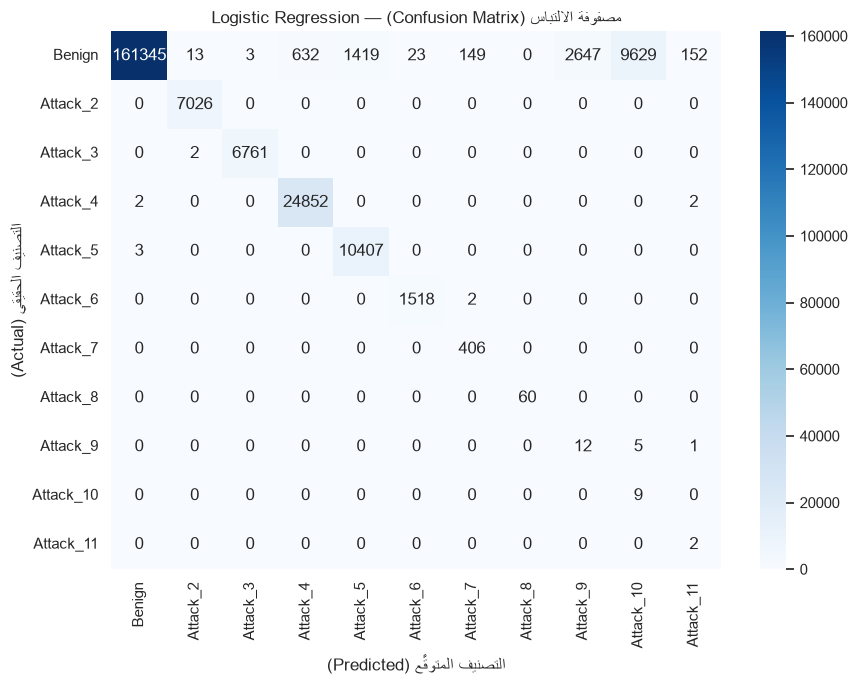

In [6]:
start = time.time()
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight=class_weights,
    random_state=RANDOM_STATE,
)
lr_model.fit(X_train, y_train)
lr_train_time = time.time() - start
print(f"وقت تدريب Logistic Regression: {lr_train_time:.1f} ثانية")

trained_models["Logistic Regression"] = lr_model
lr_pred = lr_model.predict(X_test)
metrics = evaluate_model("Logistic Regression", lr_pred, y_test)
metrics["Training Time (s)"] = lr_train_time
results["Logistic Regression"] = metrics

**ماذا فعلنا ولماذا؟**
دربنا Logistic Regression (نموذج خطي بسيط نسبياً) بنفس أوزان الفئات، ورفعنا الحد الأقصى
لعدد التكرارات (`max_iter=1000`) لأن هذا النوع من النماذج يحتاج تكرارات كثيرة حتى يتقارب
على بيانات بهذا الحجم وعدد الخصائص. هذا النموذج أبسط بكثير من Random Forest، لذلك نتوقع
أداءً أضعف عموماً، لكنه مفيد كخط أساس (Baseline) للمقارنة.

وقت تدريب Gradient Boosting (XGBoost): 206.9 ثانية


===== Gradient Boosting (XGBoost) =====
Accuracy:          0.9998
Precision (macro): 0.8798
Recall (macro):    0.9797
F1-score (macro):  0.9139

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    176012
    Attack_2       1.00      1.00      1.00      7026
    Attack_3       1.00      1.00      1.00      6763
    Attack_4       1.00      1.00      1.00     24856
    Attack_5       1.00      1.00      1.00     10410
    Attack_6       1.00      1.00      1.00      1520
    Attack_7       0.99      1.00      1.00       406
    Attack_8       1.00      1.00      1.00        60
    Attack_9       0.27      0.78      0.40        18
   Attack_10       0.75      1.00      0.86         9
   Attack_11       0.67      1.00      0.80         2

    accuracy                           1.00    227082
   macro avg       0.88      0.98      0.91    227082
weighted avg       1.00      1.00      1.00    227082



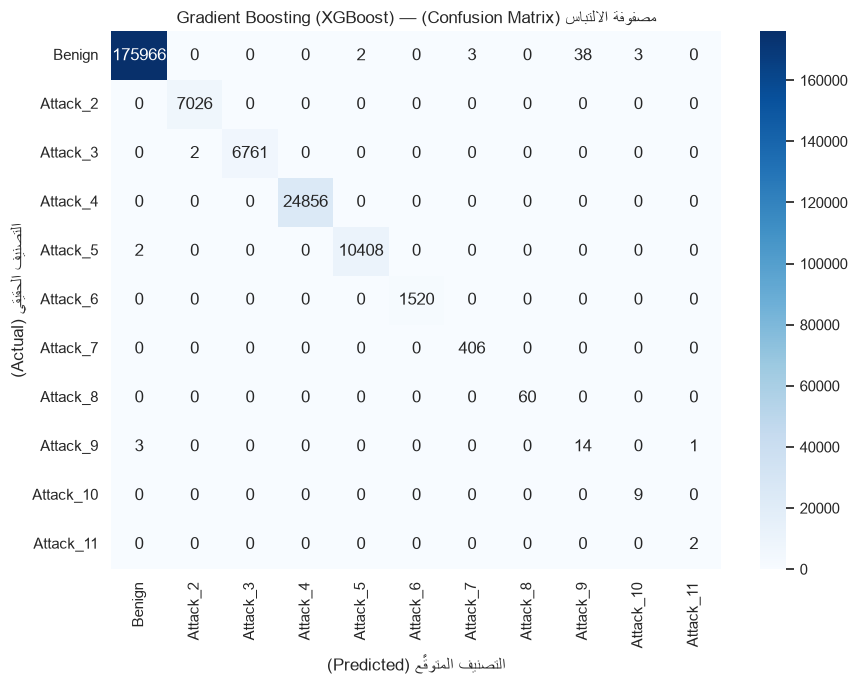

In [7]:
# XGBoost يشترط أن تكون فئات y أرقاماً متسلسلة تبدأ من 0 (0..10)، بينما فئاتنا هي 1..11.
# لذلك نستخدم LabelEncoder لتحويل الفئات إلى 0..10 قبل التدريب فقط لهذا النموذج،
# ثم نعيد التوقعات إلى الفئات الأصلية (1..11) بعد التنبؤ حتى تبقى النتائج قابلة للمقارنة
# مع النموذجين الآخرين وأسماء الفئات في label_mapping.json.
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

start = time.time()
gb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="mlogloss",
)
gb_model.fit(X_train, y_train_encoded, sample_weight=sample_weight_train)
gb_train_time = time.time() - start
print(f"وقت تدريب Gradient Boosting (XGBoost): {gb_train_time:.1f} ثانية")

trained_models["Gradient Boosting (XGBoost)"] = gb_model
gb_pred_encoded = gb_model.predict(X_test)
gb_pred = label_encoder.inverse_transform(gb_pred_encoded)
metrics = evaluate_model("Gradient Boosting (XGBoost)", gb_pred, y_test)
metrics["Training Time (s)"] = gb_train_time
results["Gradient Boosting (XGBoost)"] = metrics

**ماذا فعلنا ولماذا؟**
دربنا Gradient Boosting (عبر XGBoost) بـ 200 مرحلة تعزيز (`n_estimators=200`) وعمق شجرة
أقصى 6 (`max_depth=6`). بما أن XGBoost لا يملك معامل `class_weight`، مررنا بدلاً منه
`sample_weight` (نفس الأوزان لكل صف) مباشرة عند التدريب.

**ملاحظة مهمة (خطوة إضافية خاصة بـ XGBoost فقط):** عند أول محاولة تشغيل، فشل XGBoost
برسالة خطأ لأنه يشترط أن تكون فئات `y` أرقاماً متسلسلة تبدأ من 0 (0, 1, 2, ...)، بينما
فئاتنا الأصلية هي 1 إلى 11. Random Forest و Logistic Regression لا تفرضان هذا الشرط، لذلك
عملتا مباشرة بدون مشاكل. لحل المشكلة استخدمنا `LabelEncoder` لتحويل الفئات إلى 0..10 قبل
تدريب XGBoost فقط، ثم حوّلنا التوقعات (`predict`) مرة أخرى إلى الفئات الأصلية 1..11 عبر
`inverse_transform` قبل حساب المقاييس، حتى تبقى جدول المقارنة ومصفوفة الالتباس متّسقة مع
النموذجين الآخرين.

In [8]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[
    ["Accuracy", "Precision (macro)", "Recall (macro)", "F1-score (macro)", "Training Time (s)"]
]
comparison_df = comparison_df.sort_values("F1-score (macro)", ascending=False)

print("جدول مقارنة النماذج الثلاثة (Supervised):")
print(comparison_df.round(4).to_string())

comparison_df.round(4).to_csv(os.path.join(MODELS_DIR, "supervised_comparison.csv"))

جدول مقارنة النماذج الثلاثة (Supervised):
                             Accuracy  Precision (macro)  Recall (macro)  F1-score (macro)  Training Time (s)
Gradient Boosting (XGBoost)    0.9998             0.8798          0.9797            0.9139           206.9486
Random Forest                  0.9995             0.8515          0.9592            0.8802            56.9581
Logistic Regression            0.9353             0.6895          0.9619            0.7045           288.6457


**ماذا فعلنا ولماذا؟**
جمعنا نتائج النماذج الثلاثة في جدول واحد ورتّبناه تنازلياً حسب `F1-score (macro)` (وليس
الدقة/Accuracy فقط) لأن F1-macro يعكس الأداء على **كل الفئات بما فيها النادرة**، بينما
Accuracy وحدها يمكن أن تكون مضلِّلة (نموذج يتوقع "Benign" دائماً سيحصل على دقة عالية دون
أن يكتشف أي هجوم فعلياً). حفظنا الجدول أيضاً كملف `models/supervised_comparison.csv`
للرجوع إليه لاحقاً.

In [9]:
model_filenames = {
    "Random Forest": "random_forest.joblib",
    "Logistic Regression": "logistic_regression.joblib",
    "Gradient Boosting (XGBoost)": "gradient_boosting_xgboost.joblib",
}

for name, model in trained_models.items():
    path = os.path.join(MODELS_DIR, model_filenames[name])
    joblib.dump(model, path)
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"تم حفظ {name} -> {path} ({size_mb:.2f} MB)")

# نحفظ أيضاً LabelEncoder الخاص بـ XGBoost لأن أي استخدام مستقبلي لهذا النموذج
# (في الوكيل الذكي أو الـ API) يحتاج نفس التحويل 0..10 <-> 1..11.
encoder_path = os.path.join(MODELS_DIR, "xgboost_label_encoder.joblib")
joblib.dump(label_encoder, encoder_path)
print(f"تم حفظ LabelEncoder الخاص بـ XGBoost -> {encoder_path}")

تم حفظ Random Forest -> ..\models\random_forest.joblib (23.28 MB)
تم حفظ Logistic Regression -> ..\models\logistic_regression.joblib (0.01 MB)
تم حفظ Gradient Boosting (XGBoost) -> ..\models\gradient_boosting_xgboost.joblib (2.68 MB)
تم حفظ LabelEncoder الخاص بـ XGBoost -> ..\models\xgboost_label_encoder.joblib


**ماذا فعلنا ولماذا؟**
حفظنا كل نموذج مدرَّب في مجلد `models/` باستخدام `joblib` حتى نستطيع لاحقاً تحميله
مباشرة (بدون إعادة تدريبه) في الوكيل الذكي أو في FastAPI للتنبؤ على بيانات جديدة. حفظنا
أيضاً `xgboost_label_encoder.joblib` بشكل منفصل، لأن أي كود يستخدم نموذج XGBoost لاحقاً
يجب أن يستخدم هذا الـ Encoder نفسه لفك ترميز التوقعات (0..10) إلى الفئات الأصلية (1..11)،
وإلا ستكون النتائج غير مفهومة.

## الخلاصة

دربنا وقيّمنا النماذج الثلاثة الخاضعة للإشراف (Random Forest، Logistic Regression،
Gradient Boosting عبر XGBoost) على نفس بيانات التدريب/الاختبار، باستخدام أوزان الفئات
لمعالجة عدم التوازن، وحفظنا كل نموذج (وLabelEncoder الخاص بـ XGBoost) في `models/`.

**لم يتم بعد:** خوارزميات Unsupervised (K-Means, DBSCAN, Isolation Forest) ولا شبكة CNN
— هذه ستكون في ملفات لاحقة منفصلة كما طلبت.